# BB84 Quantum Key Distribution - Simulatore

Questo notebook implementa una **simulazione dettagliata** del protocollo **BB84**.

Include

- Preparazione degli stati di Alice
- Misurazione di Bob
- Shifting
- Stima del QBER
- Attacco intercept-resend di Eve
- Simulazione del rumore hardware (canale depolarizzato)
- Presentazione di grafici comparativi sull'effetto di Eve e del rumore

Lo scopo è mostrare la sicurezza intrinseca del protocollo BB84 e analizzarne le prestazioni in condizioni relistiche

## Import
Sono state utilizzate le librerie fondamentali per la simulazione:
- Numpy per generazione casuale e analisi numeriche
- Matplotlib per i grafici finali
- Qiskit e Aer per la simulazione dei circuiti quantistici
- NoiseModel per simulare rumore reale sugli operatori

Questi import sono gli unici strumenti necessari per simulare un BB84 completo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel, depolarizing_error
from typing import List, Tuple, Optional

## Configurazione

In questa sezione vengono definiti i parametri principali del simulatore.

- **DEFAULT_KEY_LENGTH**  (Lunghezza default della chiave)
- **PLOT_KEY_LENGTH** (Lunghezza chiave maggiore per grafici stabili)
- **N_RUNS_NOISE/N_RUNS_EVE** (Numero di simulazioni per mediare il QBER)
- **QBER_SAMPLE_FRAC** (Frazione di bit usata per stimare il QBER)

In [2]:
DEFAULT_KEY_LENGTH = 256
PLOT_KEY_LENGTH = 1024
N_RUNS_NOISE = 10
N_RUNS_EVE = 10
QBER_SAMPLE_FRAC = 0.5

## Utility BB84 (preparazione stati)

In questa sezione sonos tate definite le funzioni che generano:
- i bit di Alice
- le basi di preparazione
- le basi di misurazione di Bob

In [3]:
def prepare_alice_states(n_qubits: int) -> Tuple[np.ndarray, np.ndarray]:
    alice_bits = np.random.randint(2, size=n_qubits)
    alice_bases = np.random.randint(2, size=n_qubits)
    return alice_bits, alice_bases

def prepare_bob_bases(n_qubits: int) -> np.ndarray:
    return np.random.randint(2, size=n_qubits)

## Costruzione circuito BB84

Questa funzione costruisce il circuito quantistico che implementa:
- Preparazione dei qbit secondo Alice
- Eventuale rotazione in base X
- Misurazione nella base scelta da Bob

Questo è il cuore fisico del protocollo

In [4]:
def build_bb84_circuit(alice_bits: np.ndarray, alice_bases: np.ndarray,
                       bob_bases: np.ndarray) -> QuantumCircuit:

    n = len(alice_bits)
    qc = QuantumCircuit(n, n)

    # Preparazione di Alice
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    qc.barrier()

    # Misurazione di Bob
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)

    return qc

## Simulazione BB84 e Sifting

Questa parte esegue l'intero protocollo:
- Prepara i bit e le basi di Alice
- Costruisce e simula il circuito con/senza rumore
- Applica la procedura di shifting eliminando i bit con basi diverse

Il risultato è una chiave comune condivisa tra Alice e Bob.

In [5]:
def run_bb84_simulation(n_qubits: int,
                        noise_model: Optional[NoiseModel] = None,
                        backend_name: str = 'qasm_simulator'):

    alice_bits, alice_bases = prepare_alice_states(n_qubits)
    bob_bases = prepare_bob_bases(n_qubits)
    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases)

    simulator = Aer.get_backend(backend_name)
    job_params = {"shots": 1}
    if noise_model:
        job_params["noise_model"] = noise_model

    result = simulator.run(qc, **job_params).result()
    bob_bits_str = list(result.get_counts().keys())[0]
    bob_bits = [int(bit) for bit in reversed(bob_bits_str)]

    sifted_a, sifted_b, sifted_idx = [], [], []
    for i in range(n_qubits):
        if alice_bases[i] == bob_bases[i]:
            sifted_a.append(alice_bits[i])
            sifted_b.append(bob_bits[i])
            sifted_idx.append(i)

    return sifted_a, sifted_b, alice_bases, bob_bases, sifted_idx

## QBER e funzioni matematiche

Il QBER (Quantum Bit Error Rate) misura la quantità di errori nella chiave

Sono stati usati:
- 'calculate_true_qber' (QBER reale)
- 'binary_entropy' (Funzione usata per stimare la lunghezza della chiave sicura)

In [6]:
def calculate_true_qber(key_a, key_b):
    n = len(key_a)
    if n == 0:
        return 0.0
    errors = sum(1 for i in range(n) if key_a[i] != key_b[i])
    return errors / n

def binary_entropy(q):
    if q == 0 or q == 1:
        return 0
    return -q*np.log2(q) - (1-q)*np.log2(1-q)

## Attacco di Eve

Nel blocco sottostante è stata implementata una versione realistica dell'attacco *intercept-resend*:

- Eve intercetta un certo tasso dei qbit
- Ogni intercettazione introduce errori -> circa 25% (limite teorico BB84)

Questa funzione simula l'effetto sulla chiave filtrata.

In [7]:
# Simula l’effetto di un attacco intercept-resend su una chiave già filtrata.
# Ogni qubit intercettato introduce un errore medio del 25% dei casi.

def simulate_eve_effect_on_sifted_key(sifted_a_ideal: List[int], 
                                      interception_rate: float) -> Tuple[List[int], float]:
    sifted_b_corrupted = sifted_a_ideal.copy()
    n = len(sifted_a_ideal)
    
    for i in range(n):
        if np.random.rand() < interception_rate:
            if np.random.rand() < 0.25:
                sifted_b_corrupted[i] ^= 1  # Flip del bit

    qber = calculate_true_qber(sifted_a_ideal, sifted_b_corrupted)
    return sifted_b_corrupted, qber

## Modello di rumore hardware

Questa parte crea un modello di rumore da applicare alle porte quantistiche.

Sono stati usati
- Depolarizing error (errore fisico realistico)
- Applicato alle porte X e H

In [8]:
def build_noise_model(p):
    noise_model = NoiseModel()
    error = depolarizing_error(p, 1)
    noise_model.add_all_qubit_quantum_error(error, ['h', 'x'])
    print(f"\n=== Parametri Rumore (p = {p}) ===")
    return noise_model

## Funzione di stampa scenari

Questa utility produce un riassunto leggibile dei risultati di ogni scenario:

- Lunghezza della chiave
- Numero di errori
- QBER
- Valutazione finale (Chiave sicura o compromessa)

In [9]:
def stampa_scenario(nome, sifted_a, sifted_b, qber):
    print(f"\n--- {nome} ---")
    print("Lunghezza chiave filtrata:", len(sifted_a))
    errori = int(qber * len(sifted_a))
    print(f"Errori totali rilevati: {errori}")
    print(f"** QBER (Quantum Bit Error Rate): {qber*100:.2f}% **")

    if qber == 0:
        print("RISULTATO: SUCCESSO! QBER nullo → chiave perfetta.\n")
    elif qber < 0.11:
        print("RISULTATO: SUCCESSO! QBER basso → chiave sicura (post-correzione).\n")
    elif qber < 0.25:
        print("RISULTATO: ATTENZIONE! QBER sopra soglia → serve correzione d’errore.\n")
    else:
        print("RISULTATO: FALLIMENTO! QBER altissimo → intercettazione probabile. Chiave scartata.\n")

## Grafici finali (Eve + rumore)

Vengono prodotti due grafici:

1. **QBER vs Interception Rate**
    - mostra come aumenta il QBER in presenza di EVE
  
2. **QBER vs Rumore**
    - simula la degradazione causata dal rumore del dispositivo

Entrambi vengono salvati in un file PNG per una migliore visualizzazione.

In [10]:
def plot_qber_results(
    interception_rates, qber_eve_mean, qber_eve_std,
    noise_levels, qber_noise_mean, qber_noise_std,
    out_file='grafici_bb84.png'
):
    """Grafici comparativi per BB84 (Eve e Rumore)."""
    plt.figure(figsize=(14, 6))
    plt.rcParams.update({'font.size': 12})
    plt.suptitle("\nAnalisi delle Prestazioni del Protocollo BB84", fontsize=16, fontweight='bold')

    # ===========================
    #  GRAFICO 1 – ATTACCO DI EVE
    # ===========================
    plt.subplot(1, 2, 1)
    plt.errorbar(
        interception_rates, qber_eve_mean, yerr=qber_eve_std,
        fmt='o', capsize=4, label='QBER Simulato (media ± errore std)'
    )
    plt.plot(interception_rates, 0.25 * np.array(interception_rates),
             linestyle='--', color='r', label='Teorico: QBER = 0.25 × r')
    
    plt.axhline(0.11, linestyle=':', color='orange', label='Soglia di sicurezza (11%)')
    plt.axhline(0.25, linestyle=':', color='gray', label='Soglia massima teorica (25%)')

    plt.title("Impatto dell’Attacco Intercept-Resend (Eve)")
    plt.xlabel("Tasso di Intercettazione (r)")
    plt.ylabel("QBER risultante")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # ===========================
    #  GRAFICO 2 – RUMORE HARDWARE
    # ===========================
    plt.subplot(1, 2, 2)
    plt.errorbar(
        noise_levels, qber_noise_mean, yerr=qber_noise_std,
        fmt='s', capsize=4, label='QBER Simulato (media ± errore std)'
    )

    if len(noise_levels) > 1:
        m, b = np.polyfit(noise_levels, qber_noise_mean, 1)
        plt.plot(noise_levels, m * np.array(noise_levels) + b,
                 linestyle='--', color='r', label=f'Fit lineare (y ≈ {m:.2f}x + {b:.3f})')

    plt.axhline(0.11, linestyle=':', color='orange', label='Soglia di sicurezza (11%)')

    plt.title("Influenza del Rumore Hardware (Depolarizing)")
    plt.xlabel("Livello di Rumore (p)")
    plt.ylabel("QBER risultante")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(out_file, dpi=300)
    print(f"\nGrafici salvati in: {out_file}")

## Main (Esecuzione Scenari)

In questa sezione sono stati eseguiti:

- Scenario 1: Ideale (no Eve, no rumore)
- Scenario 2: Eve intercetta il 100% dei qbit
- Scenario 3: Rumore depolarizzante
- Generazione dei grafici finali

Questo è il blocco che produce tutta la parte dimostrativa


##############################
###   BB84 QKD – DEMO     ###
##############################

Key length per scenari: 256
Key length per grafici: 1024

--- SCENARIO 1: Ideale (No Eve, No Noise) ---
Lunghezza chiave filtrata: 135
Errori totali rilevati: 0
** QBER (Quantum Bit Error Rate): 0.00% **
RISULTATO: SUCCESSO! QBER nullo → chiave perfetta.

>>> EVE HA INTERCETTATO I QUBIT (100% Intercept-Resend)! <<<

--- SCENARIO 2: Con Eve (No Noise) ---
Lunghezza chiave filtrata: 135
Errori totali rilevati: 32
** QBER (Quantum Bit Error Rate): 23.70% **
RISULTATO: ATTENZIONE! QBER sopra soglia → serve correzione d’errore.


=== Parametri Rumore (p = 0.05) ===

--- SCENARIO 3: Con Rumore 5.0% (No Eve) ---
Lunghezza chiave filtrata: 128
Errori totali rilevati: 3
** QBER (Quantum Bit Error Rate): 2.34% **
RISULTATO: SUCCESSO! QBER basso → chiave sicura (post-correzione).


--- Generazione Grafici ---
Generazione curva Eve... (key_len=488, runs=10)
Generazione curva Rumore... (key_len=1024, runs=

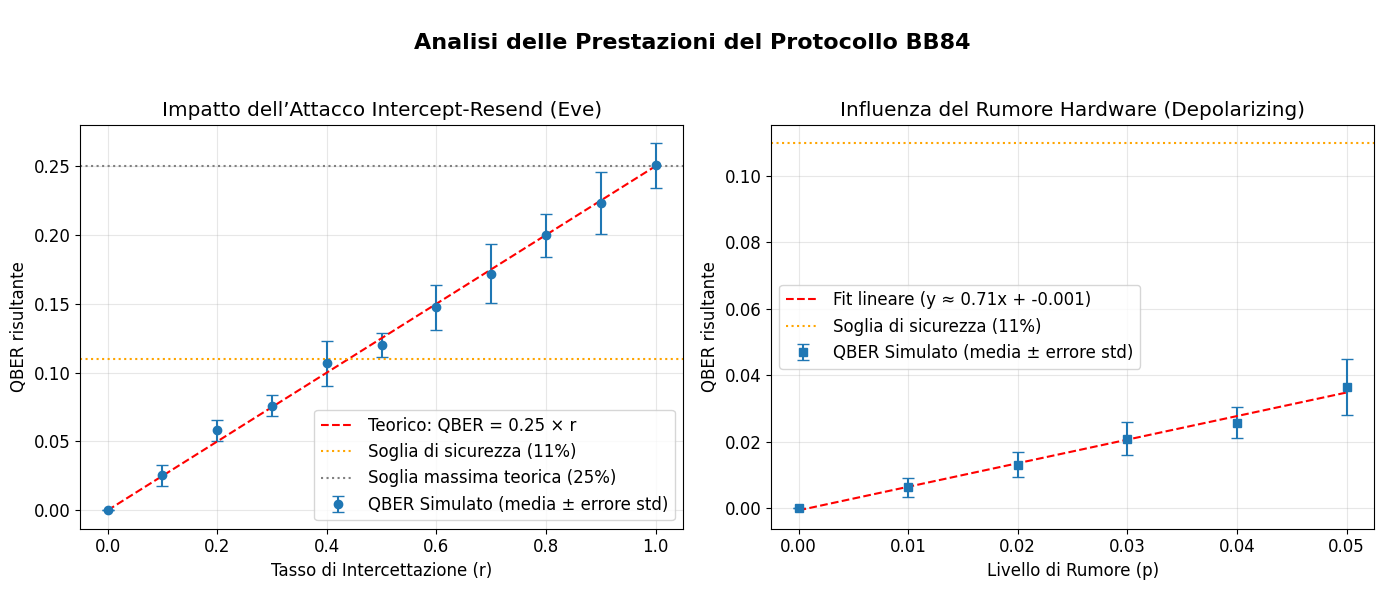

In [11]:
# Main
if __name__ == "__main__":

    print("\n##############################")
    print("###   BB84 QKD – DEMO     ###")
    print("##############################\n")

    print(f"Key length per scenari: {DEFAULT_KEY_LENGTH}")
    print(f"Key length per grafici: {PLOT_KEY_LENGTH}")

    # SCENARIO 1: IDEALE
    sifted_a, sifted_b, *_ = run_bb84_simulation(DEFAULT_KEY_LENGTH)
    qber_ideale = calculate_true_qber(sifted_a, sifted_b)
    stampa_scenario("SCENARIO 1: Ideale (No Eve, No Noise)", sifted_a, sifted_b, qber_ideale)

    # SCENARIO 2: EVE PRESENTE
    print(">>> EVE HA INTERCETTATO I QUBIT (100% Intercept-Resend)! <<<")
    bob_eve, qber_eve = simulate_eve_effect_on_sifted_key(sifted_a, interception_rate=1.0)
    stampa_scenario("SCENARIO 2: Con Eve (No Noise)", sifted_a, bob_eve, qber_eve)

    # SCENARIO 3: RUMORE
    p_scenario = 0.05
    noise_scen = build_noise_model(p_scenario)
    ka_noise, kb_noise, *_ = run_bb84_simulation(DEFAULT_KEY_LENGTH, noise_model=noise_scen)
    qber_noise = calculate_true_qber(ka_noise, kb_noise)
    stampa_scenario(f"SCENARIO 3: Con Rumore {p_scenario*100:.1f}% (No Eve)", ka_noise, kb_noise, qber_noise)

    # Generazione grafici
    print("\n--- Generazione Grafici ---")
    sifted_a_plot, _, *_ = run_bb84_simulation(PLOT_KEY_LENGTH)

    # Grafico Eve
    rates = np.linspace(0, 1, 11)
    qber_eve_mean, qber_eve_std = [], []

    print(f"Generazione curva Eve... (key_len={len(sifted_a_plot)}, runs={N_RUNS_EVE})")
    for r in rates:
        q_vals = []
        for _ in range(N_RUNS_EVE):
            _, q = simulate_eve_effect_on_sifted_key(sifted_a_plot, r)
            q_vals.append(q)
        qber_eve_mean.append(np.mean(q_vals))
        qber_eve_std.append(np.std(q_vals))

    # Grafico Rumore
    noise_levels = np.linspace(0, 0.05, 6)
    qber_noise_mean, qber_noise_std = [], []

    print(f"Generazione curva Rumore... (key_len={PLOT_KEY_LENGTH}, runs={N_RUNS_NOISE})")
    for p in noise_levels:
        if p == 0:
            qber_noise_mean.append(0.0)
            qber_noise_std.append(0.0)
            continue
        nm = build_noise_model(p)
        q_vals = []
        for _ in range(N_RUNS_NOISE):
            ka, kb, *_ = run_bb84_simulation(PLOT_KEY_LENGTH, noise_model=nm)
            q_vals.append(calculate_true_qber(ka, kb))
        qber_noise_mean.append(np.mean(q_vals))
        qber_noise_std.append(np.std(q_vals))

    # Grafico finale
    plot_qber_results(
        rates, qber_eve_mean, qber_eve_std,
        noise_levels, qber_noise_mean, qber_noise_std
    )